In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [8]:
from google.colab import files
uploaded= files.upload()

Saving StudentPerformanceFactors.csv to StudentPerformanceFactors.csv


In [11]:
df=pd.read_csv("StudentPerformanceFactors.csv")
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [13]:
df.shape

(6607, 20)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

In [14]:
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [15]:
df.columns

Index(['Hours_Studied', 'Attendance', 'Parental_Involvement',
       'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours',
       'Previous_Scores', 'Motivation_Level', 'Internet_Access',
       'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'School_Type',
       'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities',
       'Parental_Education_Level', 'Distance_from_Home', 'Gender',
       'Exam_Score'],
      dtype='object')

In [16]:
df.isnull().sum()

,0
Hours_Studied,0
Attendance,0
Parental_Involvement,0
Access_to_Resources,0
Extracurricular_Activities,0
Sleep_Hours,0
Previous_Scores,0
Motivation_Level,0
Internet_Access,0
Tutoring_Sessions,0


In [17]:
numeric_cols=df.select_dtypes(include=['number']).columns
numeric_cols

Index(['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores',
       'Tutoring_Sessions', 'Physical_Activity', 'Exam_Score'],
      dtype='object')

In [18]:
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

In [ ]:
categorical_cols= df.select_dtypes(include=['object']).columns
categorical_cols

Index(['Parental_Involvement', 'Access_to_Resources',
       'Extracurricular_Activities', 'Motivation_Level', 'Internet_Access',
       'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence',
       'Learning_Disabilities', 'Parental_Education_Level',
       'Distance_from_Home', 'Gender'],
      dtype='object')

In [22]:
categorical_cols= df.select_dtypes(include=['object']).columns
for col in categorical_cols:
  df[col]=df[col].fillna(df[col].mode()[0])
  df.isnull().sum()

In [23]:
le = LabelEncoder()

for col in df.columns:
  if df[col].dtype =='object':
    df[col]=le.fit_transform(df[col])

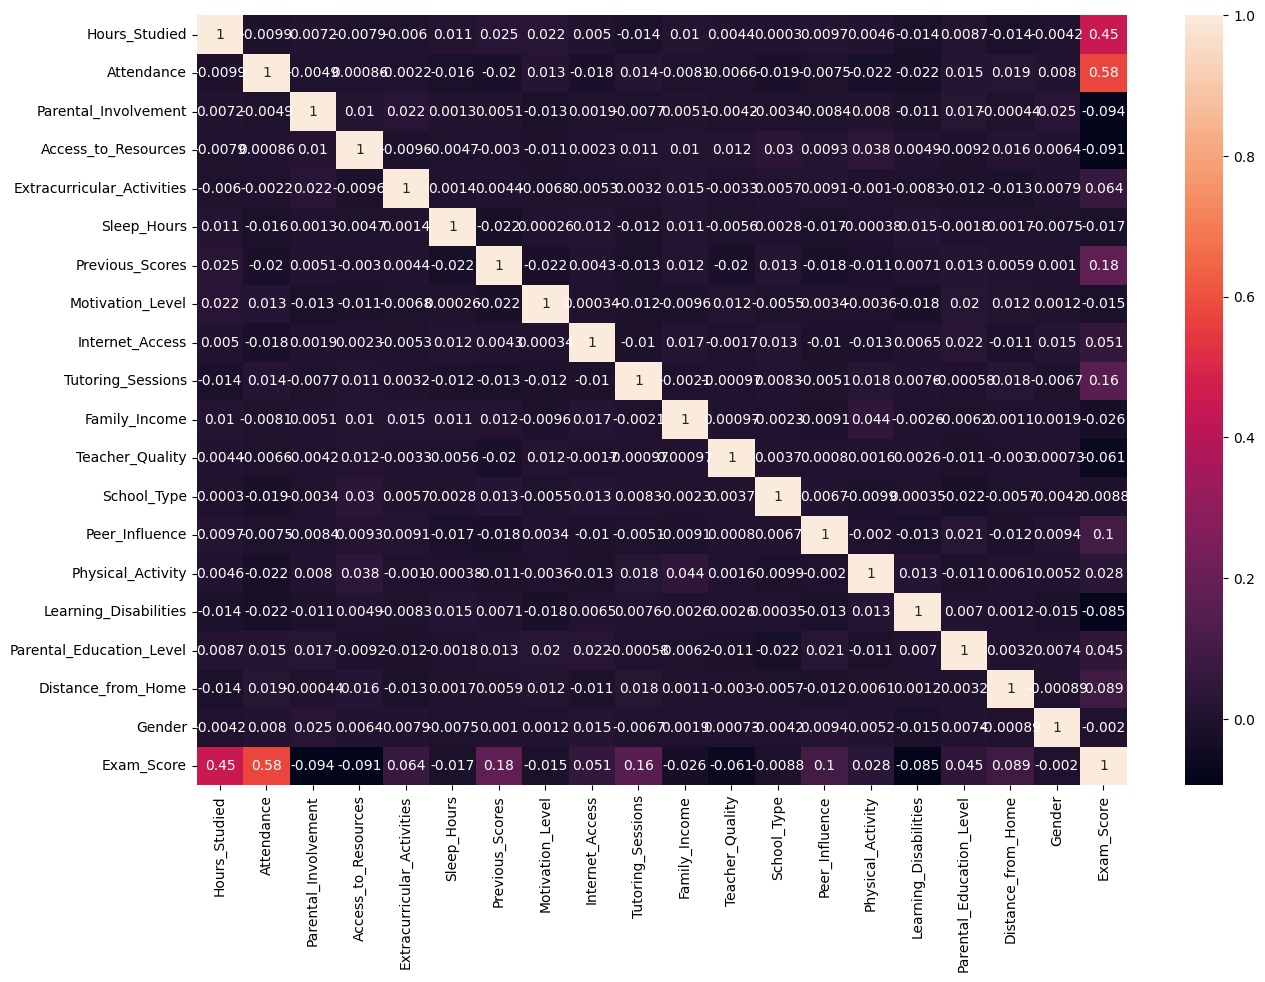

In [24]:
plt.figure(figsize=(15,10))
sns.heatmap(df.corr(),annot=True)
plt.show()

In [25]:
x= df.drop("Exam_Score",axis=1)
y= df["Exam_Score"]

In [26]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.20,random_state=42)

In [27]:
model=RandomForestRegressor(n_estimators=200,random_state=42)
model.fit(x_train,y_train)

RandomForestRegressor(n_estimators=200, random_state=42)

In [29]:
y_pred=model.predict(x_test)

In [30]:
mae=mean_absolute_error(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)
rmse=np.sqrt(mse)

r2=r2_score(y_test,y_pred)

print("MAE=",mae)
print("MSE=",mse)
print("RMSE=",rmse)
print("R2 Score=",r2)

MAE= 1.1230370650529502
MSE= 4.837678271558245
RMSE= 2.199472271150115
R2 Score= 0.6577535572753651


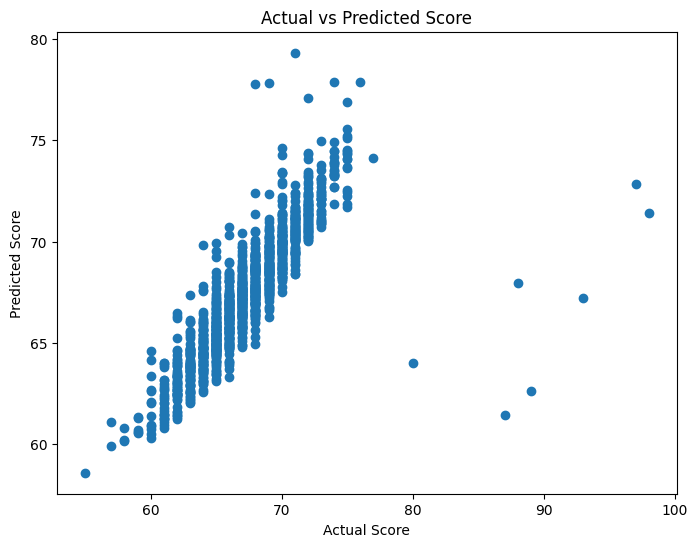

In [31]:
plt.figure(figsize=(8,6))

plt.scatter(y_test,y_pred)

plt.xlabel("Actual Score")
plt.ylabel("Predicted Score")

plt.title("Actual vs Predicted Score")

plt.show()

In [33]:
importance=pd.DataFrame({"Feature":x.columns,"Importance":model.feature_importances_})

importance=importance.sort_values(by="Importance",ascending=False)

print(importance)

                       Feature  Importance
1                   Attendance    0.380100
0                Hours_Studied    0.244292
6              Previous_Scores    0.092668
9            Tutoring_Sessions    0.036205
5                  Sleep_Hours    0.028863
14           Physical_Activity    0.028215
3          Access_to_Resources    0.027853
2         Parental_Involvement    0.027773
10               Family_Income    0.018709
13              Peer_Influence    0.018263
17          Distance_from_Home    0.017051
16    Parental_Education_Level    0.016120
7             Motivation_Level    0.012515
11             Teacher_Quality    0.011969
15       Learning_Disabilities    0.009109
12                 School_Type    0.008774
4   Extracurricular_Activities    0.008606
18                      Gender    0.007191
8              Internet_Access    0.005723


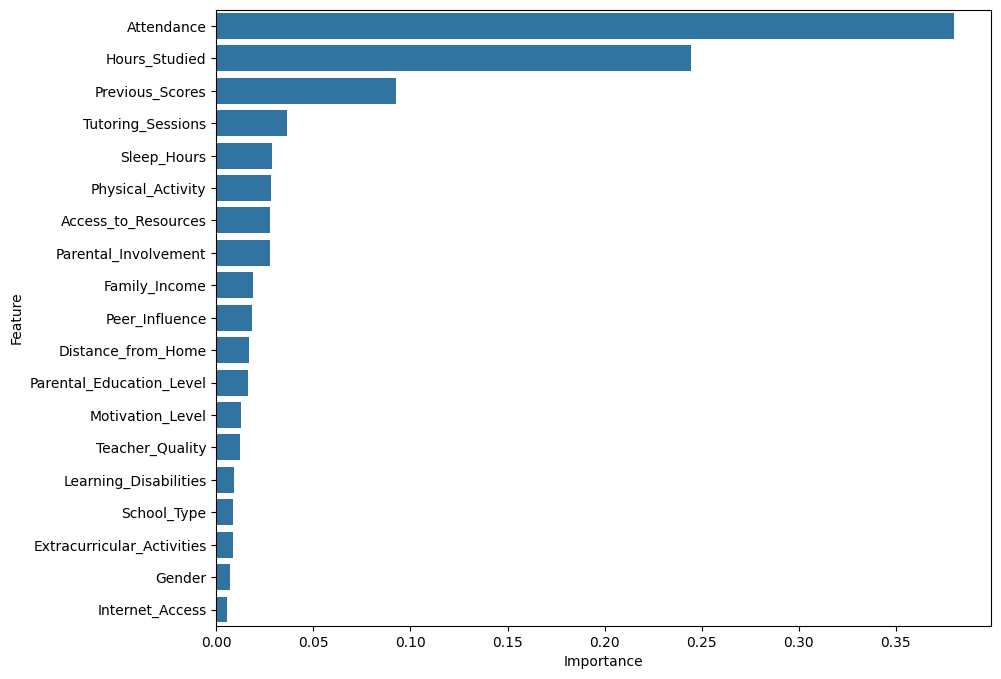

In [34]:
plt.figure(figsize=(10,8))

sns.barplot(data=importance,x="Importance",y="Feature")

plt.show()

In [36]:
import joblib
joblib.dump(model,"Student_Performance_model.pkl")

print("Model Saved Successfully")

Model Saved Successfully


In [37]:
sample_student=x.iloc[[0]]

prediction=model.predict(sample_student)

print("Predicted Exam Score:",prediction[0])

Predicted Exam Score: 67.99
